In [2]:
import numpy as np
from src import util

from src.linear_model import LinearModel

In [63]:
class LogisticRegression(LinearModel):
    """Logistic regression with Newton's Method as the solver.

    Example usage:
        > clf = LogisticRegression()
        > clf.fit(x_train, y_train)
        > clf.predict(x_eval)
    """
    def fit(self, x, y):
        """Run Newton's Method to minimize J(theta) for logistic regression.

        Args:
            x: Training example inputs. Shape (m, n).
            y: Training example labels. Shape (m,).
        """
        m,n=x.shape
        self.theta=np.zeros(n)
        def sigmoid(z):
            return 1/(1+np.e**(-z))

        def gradient(y,x,theta):
            return -1/len(y)*x.T@(y-sigmoid(x@theta))        
        def hessian(x,theta):
            m = x.shape[0]
            h=sigmoid(x@theta)
            S = np.diag(h * (1 - h))
            return (1/m) * x.T@S@x
        theta_pr=np.array(self.theta)+1
        while np.linalg.norm(self.theta-theta_pr,ord=1)>=self.eps:
            theta_pr=np.copy(self.theta)
            self.theta=self.theta- np.linalg.inv(hessian(x,self.theta))@gradient(y,x,self.theta)
            #print(self.theta)
        

    def predict(self, x):
        """Make a prediction given new inputs x.

        Args:
            x: Inputs of shape (m, n).

        Returns:
            Outputs of shape (m,).
        """
        return 1/(1+np.exp(-(x @ self.theta)))

In [64]:
x_train, y_train = util.load_dataset("data/ds1_train.csv", add_intercept=True)
x_val, y_val = util.load_dataset("data/ds1_valid.csv", add_intercept=True)
clf = LogisticRegression()
clf.fit(x_train, y_train)
predictions=clf.predict(x_val)
print(predictions[:20])
y_val[:20]

[3.84702372e-02 4.58618143e-01 6.48516560e-01 1.26972848e-01
 1.51558211e-02 3.05227211e-03 4.90934726e-15 5.88172269e-01
 1.43715867e-01 2.22143730e-03 4.82523503e-03 1.53022144e-01
 4.41043436e-04 2.50795158e-01 6.87121015e-06 5.98565217e-02
 1.56191077e-01 6.51950670e-01 2.46153957e-01 3.05499776e-02]


array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.])

In [67]:
import matplotlib.pyplot as plt 
import seaborn as sns

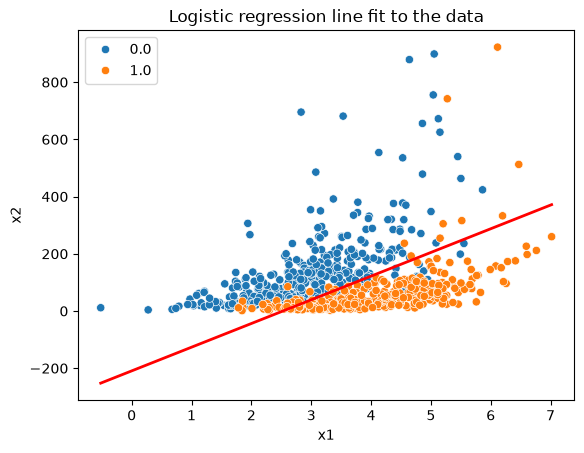

In [90]:
ax,fig=plt.subplots()
sns.scatterplot(x=x_train[:,1],y=x_train[:,2],hue=y_train)

theta=clf.theta
def calculate_x2(x1,theta):
    return -(theta[0]+theta[1]*x1)/theta[2]
x_min=np.min(x_train[:,1])
x_max=np.max(x_train[:,1])

fig.set_xlabel("x1")
fig.set_ylabel("x2")
fig.set_title("Logistic regression line fit to the data")
plt.plot([x_min,x_max ], [calculate_x2(x_min,theta), calculate_x2(x_max,theta)], linewidth=2,color='red')
plt.show()